# Assignment 3 – Image Captioning: Shared Data Preparation
**Dataset:** VizWiz-Captions Validation Set  
**Purpose:** This notebook handles all data loading, cleaning, tokenization, vocabulary building, train/val/test splitting, and DataLoader creation shared across all group members.

## 1. Imports and Configuration

In [31]:
import os
import json
import re
import random
import zipfile
import urllib.request
from collections import Counter
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paths ──
DATA_DIR       = Path("/workspace/assessments/3/code/dataset")
IMAGE_DIR      = DATA_DIR / "val"
ANNOTATION_DIR = DATA_DIR / "annotations"
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Torch version: 2.10.0+cu126
CUDA available: True
Using device: cuda


## 2. Download and Extract Dataset
Download the VizWiz validation images and caption annotations.  
**Note:** If the files are already present locally, this cell is skipped.

In [17]:
# Download helpers
IMG_URL  = "https://vizwiz.cs.colorado.edu/VizWiz_final/images/val.zip"
ANN_URL  = "https://vizwiz.cs.colorado.edu/VizWiz_final/caption/annotations.zip"

def download_if_missing(url, dest):
    if not dest.exists():
        print(f"Downloading {url} ...")
        urllib.request.urlretrieve(url, dest)
        print(f"  Saved to {dest}")
    else:
        print(f"  Already exists: {dest}")

download_if_missing(IMG_URL, DATA_DIR / "val.zip")
download_if_missing(ANN_URL, DATA_DIR / "annotations.zip")

# Extract
if not IMAGE_DIR.exists():
    print("Extracting images...")
    with zipfile.ZipFile(DATA_DIR / "val.zip", "r") as z:
        z.extractall(DATA_DIR)

if not ANNOTATION_DIR.exists():
    print("Extracting annotations...")
    with zipfile.ZipFile(DATA_DIR / "annotations.zip", "r") as z:
        z.extractall(DATA_DIR)

print(f"Images directory: {IMAGE_DIR}  ({len(list(IMAGE_DIR.glob('*.jpg')))} images)")
print(f"Annotations directory: {ANNOTATION_DIR}")

  Already exists: C:\Users\gowth\OneDrive\Desktop\DL Assignment 3\DATA\val.zip
  Already exists: C:\Users\gowth\OneDrive\Desktop\DL Assignment 3\DATA\annotations.zip
Images directory: C:\Users\gowth\OneDrive\Desktop\DL Assignment 3\DATA\val  (7750 images)
Annotations directory: C:\Users\gowth\OneDrive\Desktop\DL Assignment 3\DATA\annotations


## 3. Load and Inspect Annotations

In [32]:
# The annotations file follows COCO format
ann_file = ANNOTATION_DIR / "val.json"
with open(ann_file, "r") as f:
    annotations = json.load(f)

print("Top-level keys:", list(annotations.keys()))
print(f"Number of images : {len(annotations['images'])}")
print(f"Number of captions: {len(annotations['annotations'])}")

# Show a sample
print("\nSample image entry:", json.dumps(annotations['images'][0], indent=2))
print("\nSample caption entry:", json.dumps(annotations['annotations'][0], indent=2))

Top-level keys: ['info', 'images', 'annotations']
Number of images : 7750
Number of captions: 38750

Sample image entry: {
  "file_name": "VizWiz_val_00000000.jpg",
  "vizwiz_url": "https://ivc.ischool.utexas.edu/VizWiz_visualization_img/VizWiz_val_00000000.jpg",
  "id": 23431,
  "text_detected": true
}

Sample caption entry: {
  "caption": "A computer screen shows a repair prompt on the screen.",
  "image_id": 23431,
  "is_precanned": false,
  "is_rejected": false,
  "id": 117155,
  "text_detected": true
}


In [33]:
# Build a mapping: image_id -> file_name
id_to_file = {img["id"]: img["file_name"] for img in annotations["images"]}

# Build mapping: image_id -> list of captions
# Filter out rejected and pre-canned annotations (template responses, not real descriptions)
from collections import defaultdict
id_to_captions = defaultdict(list)
skipped_rejected = 0
skipped_precanned = 0
for ann in annotations["annotations"]:
    if ann.get("is_rejected", False):
        skipped_rejected += 1
        continue
    if ann.get("is_precanned", False):
        skipped_precanned += 1
        continue
    id_to_captions[ann["image_id"]].append(ann["caption"])

print(f"Skipped {skipped_rejected} rejected + {skipped_precanned} pre-canned captions")
print(f"Total unique images with valid captions: {len(id_to_captions)}")
# Show captions for one image
sample_id = list(id_to_captions.keys())[0]
print(f"\nImage: {id_to_file[sample_id]}")
for i, cap in enumerate(id_to_captions[sample_id]):
    print(f"  Caption {i+1}: {cap}")

Skipped 964 rejected + 4641 pre-canned captions
Total unique images with valid captions: 7542

Image: VizWiz_val_00000000.jpg
  Caption 1: A computer screen shows a repair prompt on the screen.
  Caption 2: a computer screen with a repair automatically pop up
  Caption 3: partial computer screen showing the need of repairs
  Caption 4: Part of a computer monitor showing a computer repair message.
  Caption 5: The top of a laptop with a blue background and dark blue text.


## 4. Visualize Sample Images and Captions

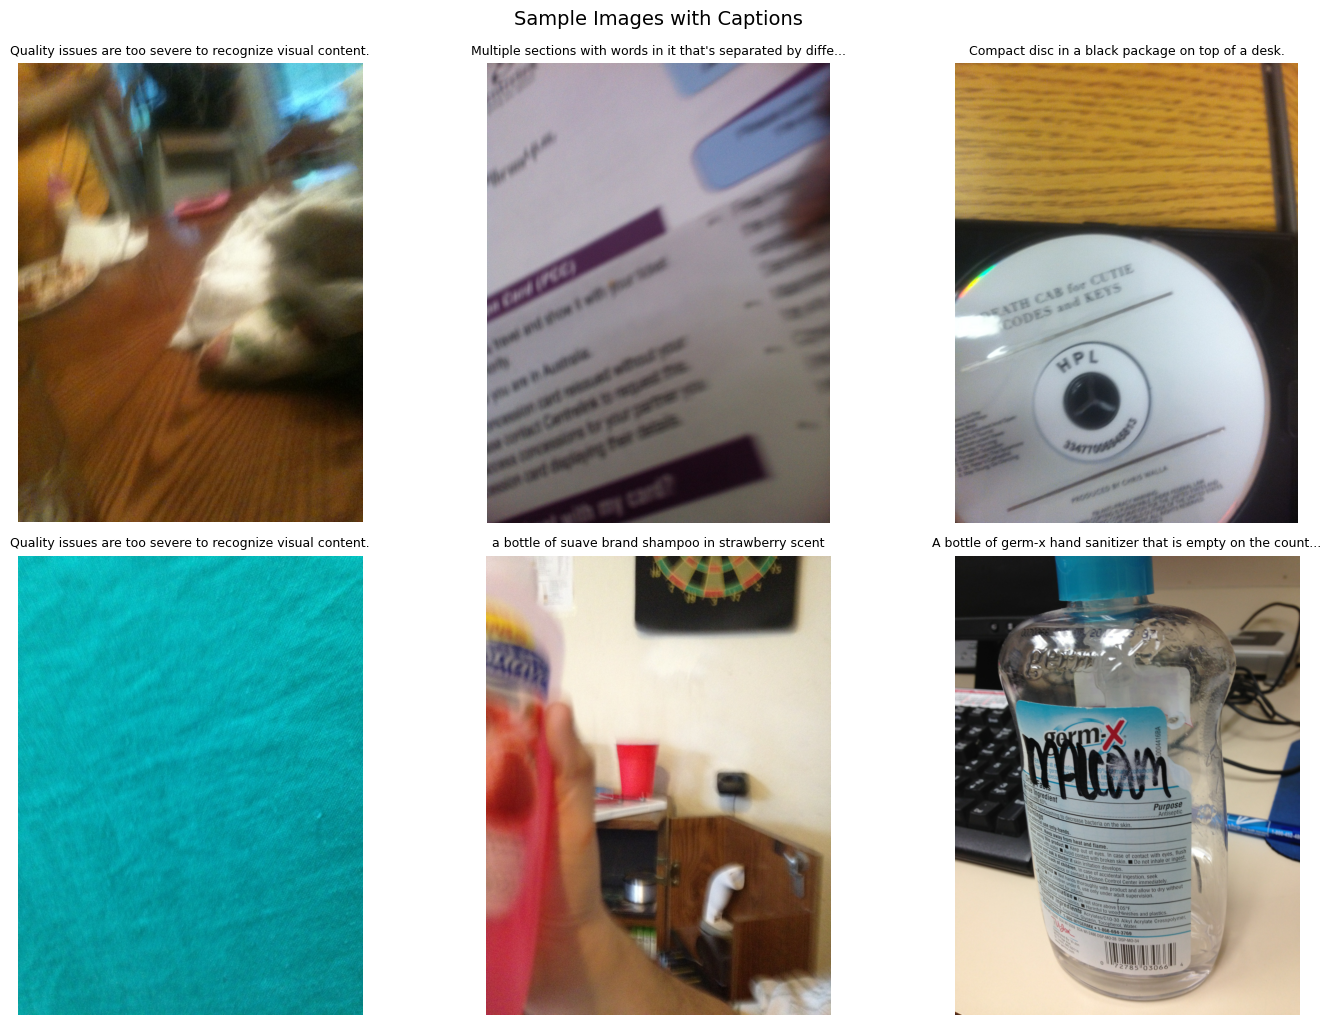

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
sample_ids = random.sample(list(id_to_captions.keys()), 6)

for ax, img_id in zip(axes.flatten(), sample_ids):
    img_path = IMAGE_DIR / id_to_file[img_id]
    try:
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        # Show first caption only
        cap = id_to_captions[img_id][0]
        ax.set_title(cap[:60] + "..." if len(cap) > 60 else cap, fontsize=9, wrap=True)
    except Exception as e:
        ax.set_title(f"Error: {e}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.suptitle("Sample Images with Captions", y=1.02, fontsize=14)
plt.show()

## 5. Caption Cleaning and Tokenization
We apply the following preprocessing:
1. Lowercase all text
2. Remove special characters and extra whitespace
3. Add `<start>` and `<end>` tokens to each caption

In [34]:
def clean_caption(caption):
    """Clean and normalise a single caption string."""
    caption = caption.lower().strip()
    # Remove everything except letters, numbers, spaces, and apostrophes
    caption = re.sub(r"[^a-z0-9\s']", " ", caption)
    # Collapse multiple spaces
    caption = re.sub(r"\s+", " ", caption).strip()
    return caption

# Clean all captions
cleaned_captions = {}
for img_id, caps in id_to_captions.items():
    cleaned = [clean_caption(c) for c in caps if len(c.strip()) > 0]
    if cleaned:
        cleaned_captions[img_id] = cleaned

print(f"Images with valid captions: {len(cleaned_captions)}")
# Show before / after
sample_id = list(cleaned_captions.keys())[0]
print(f"\nOriginal : {id_to_captions[sample_id][0]}")
print(f"Cleaned  : {cleaned_captions[sample_id][0]}")

Images with valid captions: 7542

Original : A computer screen shows a repair prompt on the screen.
Cleaned  : a computer screen shows a repair prompt on the screen


In [35]:
def tokenize(caption):
    """Simple whitespace tokenizer returning list of tokens."""
    return caption.split()

# Example
sample_cap = cleaned_captions[sample_id][0]
print("Tokens:", tokenize(sample_cap))

Tokens: ['a', 'computer', 'screen', 'shows', 'a', 'repair', 'prompt', 'on', 'the', 'screen']


## 6. Build Vocabulary
We build a vocabulary from the training split. Words appearing fewer than a
frequency threshold are replaced with `<unk>`.

In [36]:
# Special tokens
PAD_TOKEN   = "<pad>"
START_TOKEN = "<start>"
END_TOKEN   = "<end>"
UNK_TOKEN   = "<unk>"
SPECIAL_TOKENS = [PAD_TOKEN, START_TOKEN, END_TOKEN, UNK_TOKEN]

MIN_WORD_FREQ = 5  # minimum occurrences to keep a word

class Vocabulary:
    """Maps between words and integer indices."""
    def __init__(self, freq_threshold=MIN_WORD_FREQ):
        self.freq_threshold = freq_threshold
        self.word2idx = {}
        self.idx2word = {}
        self.word_freq = Counter()
        # Reserve special tokens
        for idx, tok in enumerate(SPECIAL_TOKENS):
            self.word2idx[tok] = idx
            self.idx2word[idx] = tok

    def build(self, captions_list):
        """Build vocabulary from a list of caption strings."""
        for caption in captions_list:
            tokens = tokenize(caption)
            self.word_freq.update(tokens)

        idx = len(SPECIAL_TOKENS)
        for word, freq in self.word_freq.items():
            if freq >= self.freq_threshold and word not in self.word2idx:
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                idx += 1

        print(f"Total unique tokens in corpus  : {len(self.word_freq)}")
        print(f"Vocabulary size (freq >= {self.freq_threshold}): {len(self.word2idx)}")

    def encode(self, caption):
        """Convert caption string -> list of indices with <start>/<end>."""
        tokens = tokenize(caption)
        encoded = [self.word2idx[START_TOKEN]]
        encoded += [self.word2idx.get(t, self.word2idx[UNK_TOKEN]) for t in tokens]
        encoded.append(self.word2idx[END_TOKEN])
        return encoded

    def decode(self, indices):
        """Convert list of indices -> string, stopping at <end>."""
        words = []
        for idx in indices:
            word = self.idx2word.get(idx, UNK_TOKEN)
            if word == END_TOKEN:
                break
            if word not in (PAD_TOKEN, START_TOKEN):
                words.append(word)
        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)

vocab = Vocabulary(freq_threshold=MIN_WORD_FREQ)

## 7. Train / Validation / Test Split
We split the image IDs into 80% train, 10% validation, 10% test.

In [37]:
all_ids = sorted(cleaned_captions.keys())
random.shuffle(all_ids)

n = len(all_ids)
train_end = int(0.8 * n)
val_end   = int(0.9 * n)

train_ids = all_ids[:train_end]
val_ids   = all_ids[train_end:val_end]
test_ids  = all_ids[val_end:]

print(f"Train : {len(train_ids)} images")
print(f"Val   : {len(val_ids)} images")
print(f"Test  : {len(test_ids)} images")

# Build vocabulary from TRAINING captions only
train_captions_flat = []
for img_id in train_ids:
    train_captions_flat.extend(cleaned_captions[img_id])

vocab.build(train_captions_flat)
print(f"\nFinal vocab size: {len(vocab)}")

Train : 6033 images
Val   : 754 images
Test  : 755 images
Total unique tokens in corpus  : 10052
Vocabulary size (freq >= 5): 3519

Final vocab size: 3519


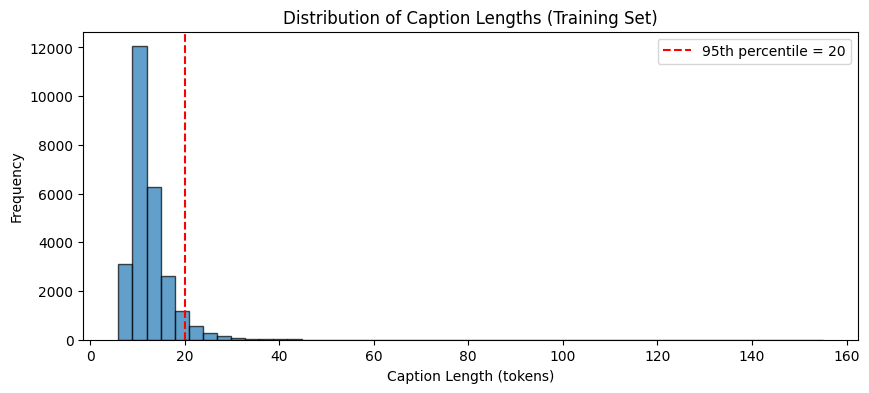

MAX_CAPTION_LEN (95th pct + 2): 22


In [38]:
# Caption length distribution (training set)
lengths = [len(tokenize(c)) for c in train_captions_flat]
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Caption Length (tokens)")
plt.ylabel("Frequency")
plt.title("Distribution of Caption Lengths (Training Set)")
plt.axvline(np.percentile(lengths, 95), color="red", linestyle="--",
            label=f"95th percentile = {int(np.percentile(lengths, 95))}")
plt.legend()
plt.show()

MAX_CAPTION_LEN = int(np.percentile(lengths, 95)) + 2  # +2 for <start>/<end>
print(f"MAX_CAPTION_LEN (95th pct + 2): {MAX_CAPTION_LEN}")

## 8. PyTorch Dataset and DataLoader
Each sample returns a transformed image tensor and a padded caption tensor.

In [39]:
# Image transforms
# Training: augmentation (Resize shorter edge to 256, then random crop to 224)
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Eval: deterministic (Resize shorter edge to 256, then centre crop to 224)
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [40]:
class VizWizCaptionDataset(Dataset):
    """
    VizWiz Image-Captioning dataset.
    
    For training we randomly select one of the five captions per image
    each epoch (data augmentation). For evaluation we keep all captions
    accessible per image.
    """
    def __init__(self, image_ids, captions_dict, vocab, id_to_file, image_dir,
                 transform=None, max_len=50, mode="train"):
        self.image_ids = image_ids
        self.captions_dict = captions_dict
        self.vocab = vocab
        self.id_to_file = id_to_file
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.max_len = max_len
        self.mode = mode

        if mode == "train":
            # Flatten: one (image_id, caption) pair per entry
            self.samples = []
            for img_id in image_ids:
                for cap in captions_dict[img_id]:
                    self.samples.append((img_id, cap))
        else:
            self.samples = [(img_id, captions_dict[img_id]) for img_id in image_ids]

    def __len__(self):
        return len(self.samples)

    def _load_image(self, img_id):
        path = self.image_dir / self.id_to_file[img_id]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

    def __getitem__(self, index):
        if self.mode == "train":
            img_id, caption = self.samples[index]
            img = self._load_image(img_id)
            encoded = self.vocab.encode(caption)
            raw_length = len(encoded)
            # Pad / truncate
            if raw_length < self.max_len:
                encoded += [self.vocab.word2idx[PAD_TOKEN]] * (self.max_len - raw_length)
            else:
                encoded = encoded[:self.max_len - 1] + [self.vocab.word2idx[END_TOKEN]]
                raw_length = self.max_len
            caption_tensor = torch.tensor(encoded, dtype=torch.long)
            length = raw_length
            return img, caption_tensor, length
        else:
            img_id, captions_list = self.samples[index]
            img = self._load_image(img_id)
            # For eval, return all reference captions as strings
            return img, captions_list, img_id


def collate_train(batch):
    """Custom collate for training: sort by caption length (descending)."""
    batch.sort(key=lambda x: x[2], reverse=True)
    images, captions, lengths = zip(*batch)
    images = torch.stack(images, 0)
    captions = torch.stack(captions, 0)
    lengths = torch.tensor(lengths, dtype=torch.long)
    return images, captions, lengths


def collate_eval(batch):
    """Custom collate for evaluation."""
    images, all_captions, img_ids = zip(*batch)
    images = torch.stack(images, 0)
    return images, list(all_captions), list(img_ids)

In [41]:
# Create datasets
train_dataset = VizWizCaptionDataset(
    train_ids, cleaned_captions, vocab, id_to_file, IMAGE_DIR,
    transform=train_transform, max_len=MAX_CAPTION_LEN, mode="train"
)

val_dataset = VizWizCaptionDataset(
    val_ids, cleaned_captions, vocab, id_to_file, IMAGE_DIR,
    transform=eval_transform, max_len=MAX_CAPTION_LEN, mode="eval"
)

test_dataset = VizWizCaptionDataset(
    test_ids, cleaned_captions, vocab, id_to_file, IMAGE_DIR,
    transform=eval_transform, max_len=MAX_CAPTION_LEN, mode="eval"
)

print(f"Train samples (image-caption pairs): {len(train_dataset)}")
print(f"Val   samples (unique images)      : {len(val_dataset)}")
print(f"Test  samples (unique images)      : {len(test_dataset)}")

Train samples (image-caption pairs): 26436
Val   samples (unique images)      : 754
Test  samples (unique images)      : 755


In [42]:
BATCH_SIZE = 32
NUM_WORKERS = 0  # Use 0 to avoid multiprocessing hangs in notebooks

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, collate_fn=collate_train, pin_memory=False
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=collate_eval, pin_memory=False
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=collate_eval, pin_memory=False
)

# Quick sanity check
images, captions, lengths = next(iter(train_loader))
print(f"Batch images shape : {images.shape}")
print(f"Batch captions shape: {captions.shape}")
print(f"Batch lengths       : {lengths[:5]}")
print(f"Sample decoded      : {vocab.decode(captions[0].tolist())}")


Batch images shape : torch.Size([32, 3, 224, 224])
Batch captions shape: torch.Size([32, 22])
Batch lengths       : tensor([22, 22, 22, 21, 19])
Sample decoded      : the cover of a book with the words <unk> <unk> <unk> written on it along with the picture of a


## 9. Save Shared Artefacts
Save the vocabulary and split IDs so each student can load them in their own notebook.

In [44]:
import pickle

# Save vocab as plain dicts to avoid pickle class-loading issues
shared_data = {
    "vocab_word2idx": vocab.word2idx,
    "vocab_idx2word": vocab.idx2word,
    "train_ids": train_ids,
    "val_ids": val_ids,
    "test_ids": test_ids,
    "cleaned_captions": dict(cleaned_captions),
    "id_to_file": id_to_file,
    "max_caption_len": MAX_CAPTION_LEN,
}

save_path = DATA_DIR / "shared_data.pkl"
with open(save_path, "wb") as f:
    pickle.dump(shared_data, f)

print(f"Saved shared artefacts to {save_path}")
print(f"  Vocab size      : {len(vocab)}")
print(f"  Train/Val/Test  : {len(train_ids)}/{len(val_ids)}/{len(test_ids)}")
print(f"  Max caption len : {MAX_CAPTION_LEN}")


Saved shared artefacts to /workspace/assessments/3/code/dataset/shared_data.pkl
  Vocab size      : 3519
  Train/Val/Test  : 6033/754/755
  Max caption len : 22


## Summary
This notebook prepared the VizWiz-Captions validation dataset:

- **Downloaded** and extracted ~7.7k validation images with 5 captions each.
- **Cleaned** captions (lowercased, removed special characters).
- **Built** a frequency-filtered vocabulary from the training split.
- **Split** the data 80/10/10 into train, validation, and test sets.
- **Created** PyTorch `Dataset` and `DataLoader` classes with proper collation.
- **Saved** all shared artefacts (`shared_data.pkl`) for individual model notebooks.

Each group member should now use `shared_data.pkl` in their own notebook.